## Question 1 (Camera Projection)

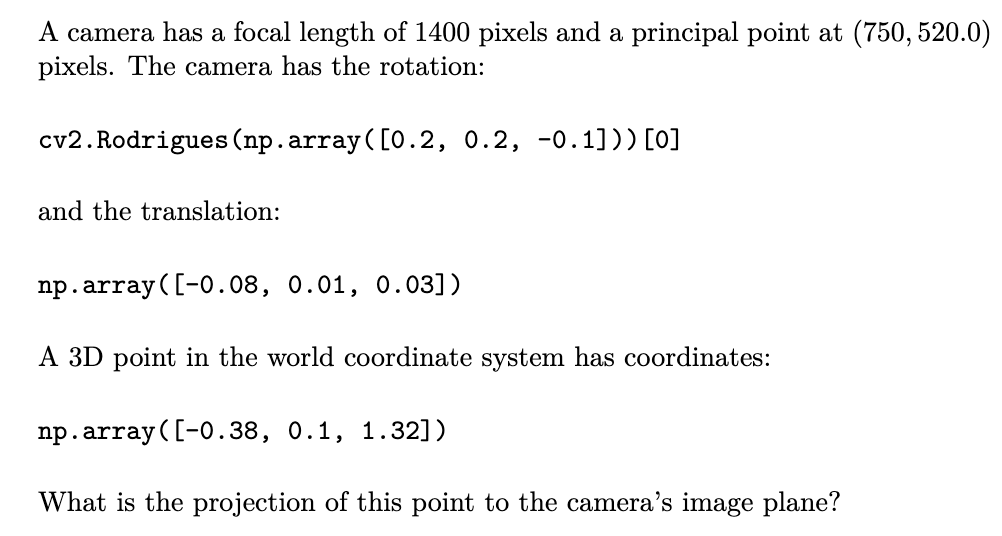

In [3]:
import numpy as np
import cv2

FocalLength = 1400 
PrincipalPoint = (750, 520.0)

# Camera rotation
R = cv2.Rodrigues(np.array([0.2, 0.2, -0.1]))[0]
# Camera translation
t = np.array([-0.08, 0.01, 0.03])
#3D point in world coordinates
P_world = np.array([-0.38, 0.1, 1.32])

# What is the projection of this point to the cameras image plane? 

# 1) First move is to define Intrinsic Camera Matrix (K) 
K = np.array([[FocalLength, 0, PrincipalPoint[0]], 
              [0, FocalLength, PrincipalPoint[1]], 
              [0, 0, 1]])

#Just another way to see how to insert the values in the matrix
K1 = np.array([[1400, 0, 750], 
              [0, 1400, 520], 
              [0, 0, 1]])

# 2) Transform to Camera Space with formula: P_camera = R * P_world + t
P_camera = R @ P_world + t
print("P_camera: ", P_camera)

# 3) Project to image plane with formula: p_image = K * P_camera
p_image = K @ P_camera
print("p_image: ", p_image)

P_camera:  [-0.19177883 -0.135751    1.39494034]
p_image:  [777.71489132 535.31758426   1.39494034]


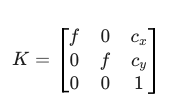

In [4]:
# 4) Final step = Normalize the coordinates by dividing by the last element
p_image_normalized = p_image / p_image[2]
print("p_image_normalized: ", p_image_normalized)

p_image_normalized:  [557.52555675 383.75661509   1.        ]


## Question 2 (Homography Estimation)


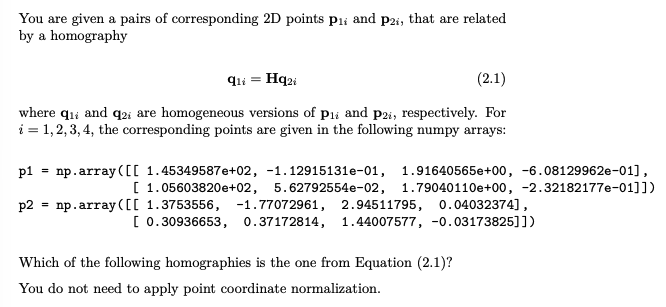

In [13]:
## To understand this exercise: 
# Homography matrix has 8 degrees of freedom, so we need 4 points to solve for it. (9th element is scale factor)
# i = 1, 2, 3, 4 (exactly 4 points)

# Use the full scientific notation values from the prompt
p1 = np.array([
    [1.45349587e+02, -1.12915131e-01, 1.91640565e+00, -6.08129962e-01],
    [1.05603820e+02, 5.62792554e-02, 1.79040110e+00, -2.32182177e-01]
]).T

p2 = np.array([
    [1.3753556, -1.77072961, 2.94511795, 0.04032374],
    [0.30936653, 0.37172814, 1.44007577, -0.03173825]
]).T

## Look at the Homography equation 2.1: (p1 = H * p2)
# 1 ) Calculate homography matrix
H = cv2.findHomography(p2, p1)[0]
print("Homography Matrix H: ", H)

Homography Matrix H:  [[-0.21161806 -0.25066191 -0.57876429]
 [-0.27191854 -0.30516881 -0.21991175]
 [-0.83009535  0.43688786  1.        ]]


Source points (srcPoints): p2, 
Destination points (dstPoints): p1
​

In [ ]:
# Scale so H[0,0] = 1.0
H_scaled = H / H[0, 0]
print(H_scaled)

[[ 1.          1.18450151  2.73494755]
 [ 1.28494962  1.44207355  1.03919177]
 [ 3.92261111 -2.06451125 -4.72549463]]
